# 4.1 Análisis Exploratorio (EDA)

## Datos obtenidos de la tabla raw

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../Datos/Staging/accidentes_staging.csv')

sns.set_theme(style="whitegrid")

C:\Users\Sara\AppData\Local\Temp\ipykernel_26744\3835005684.py:5: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../Datos/Staging/accidentes_staging.csv')


In [2]:
# 1. Configurar límites de visualización al infinito
pd.set_option('display.max_columns', None)  # Muestra todas las columnas de lado a lado
pd.set_option('display.max_rows', None)     # Muestra todas las filas del reporte abajo
pd.set_option('display.width', 1000)        # Evita que rompa la tabla hacia abajo con el signo \

# 2. Imprimir el resumen numérico completo
print("--- Resumen Estadístico Numérico Completo ---")
display(df.describe()) 

# 3. Imprimir el resumen categórico (incluyendo TW y textos) completo
print("\n--- Resumen Estadístico Categórico Completo ---")
display(df.describe(include=['object']))

--- Resumen Estadístico Numérico Completo ---


,Lon,Lat,OBJECTID,PERIODO,Mes,Dia,Hora_num
count,125122.000000,125122.000000,125122.000000,125122.000000,125122.000000,125122.000000,125122.000000
mean,-75.577059,6.250224,628445.870686,2017.999169,6.665063,15.623735,13.262728
std,0.019038,0.028559,91283.479422,0.823582,3.404394,8.745684,5.241392
min,-75.701661,6.166846,503352.000000,2017.000000,1.000000,1.000000,0.000000
25%,-75.586578,6.231896,537442.250000,2017.000000,4.000000,8.000000,9.000000
50%,-75.574821,6.250107,665085.500000,2018.000000,7.000000,16.000000,14.000000
75%,-75.565207,6.271176,720792.750000,2019.000000,10.000000,23.000000,17.000000
max,-75.480742,6.368394,758669.000000,2019.000000,12.000000,31.000000,23.000000



--- Resumen Estadístico Categórico Completo ---


,RADICADO,HORA,Dia_sem,CLASE,DIRECCION,DIRECCION_ENC,CBML,TIPO_GEOCOD,GRAVEDAD,BARRIO,COMUNA,DISENO,FECHA,TW,Dia_Sem_REAL
count,125117,125122,125122,125122,125122,125122,125122,125122,125122,125122,125122,124693,125122,125122,125122
unique,125102,2976,7,7,22673,22086,472,4456,3,322,81,12,1095,22897,7
top,62196,05:00 PM,VIERNES,CHOQUE,CR 64 C CL 78,CR 064 C 078 000 00000,1019,Malla vial,HERIDO,lacandelaria,La Candelaria,Tramo de via,2017-08-04,2019-09-06 07:00:00,VIERNES
freq,3,1059,20141,86068,561,584,3020,91379,66714,3037,25844,76819,216,33,20141


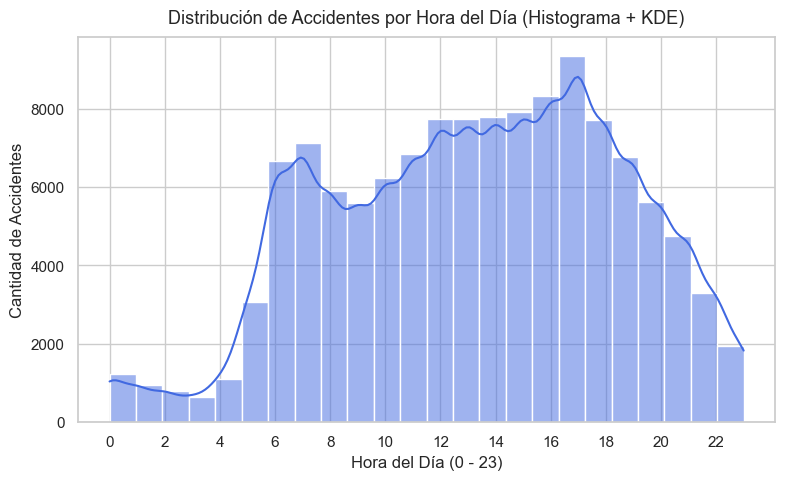

In [3]:
plt.figure(figsize=(9, 5))
# Graficar la distribución de la columna de horas
sns.histplot(data=df, x='Hora_num', kde=True, bins=24, color='royalblue')

plt.title('Distribución de Accidentes por Hora del Día (Histograma + KDE)', fontsize=13, pad=10)
plt.xlabel('Hora del Día (0 - 23)')
plt.ylabel('Cantidad de Accidentes')
plt.xticks(range(0, 24, 2))
plt.show()

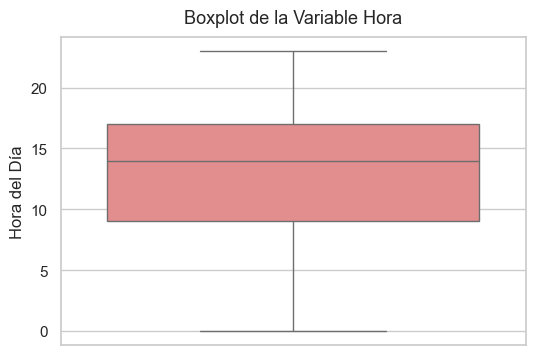

In [4]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, y='Hora_num', color='lightcoral')

plt.title('Boxplot de la Variable Hora', fontsize=13, pad=10)
plt.ylabel('Hora del Día')
plt.show()

C:\Users\Sara\AppData\Local\Temp\ipykernel_26744\1170927518.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='CLASE', order=order, palette='viridis')


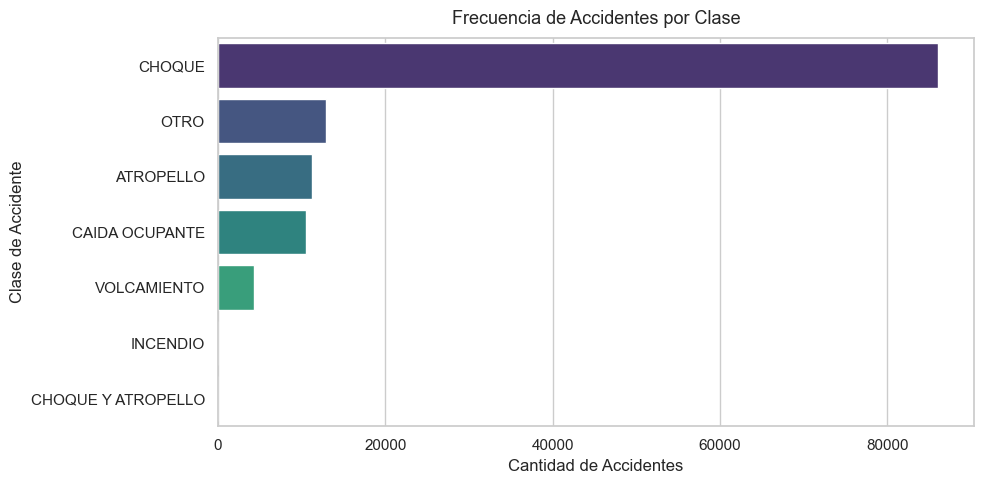

In [5]:
plt.figure(figsize=(10, 5))
# Ordenar las barras de mayor a menor frecuencia
order = df['CLASE'].value_counts().index
sns.countplot(data=df, y='CLASE', order=order, palette='viridis')

plt.title('Frecuencia de Accidentes por Clase', fontsize=13, pad=10)
plt.xlabel('Cantidad de Accidentes')
plt.ylabel('Clase de Accidente')
plt.tight_layout()
plt.show()

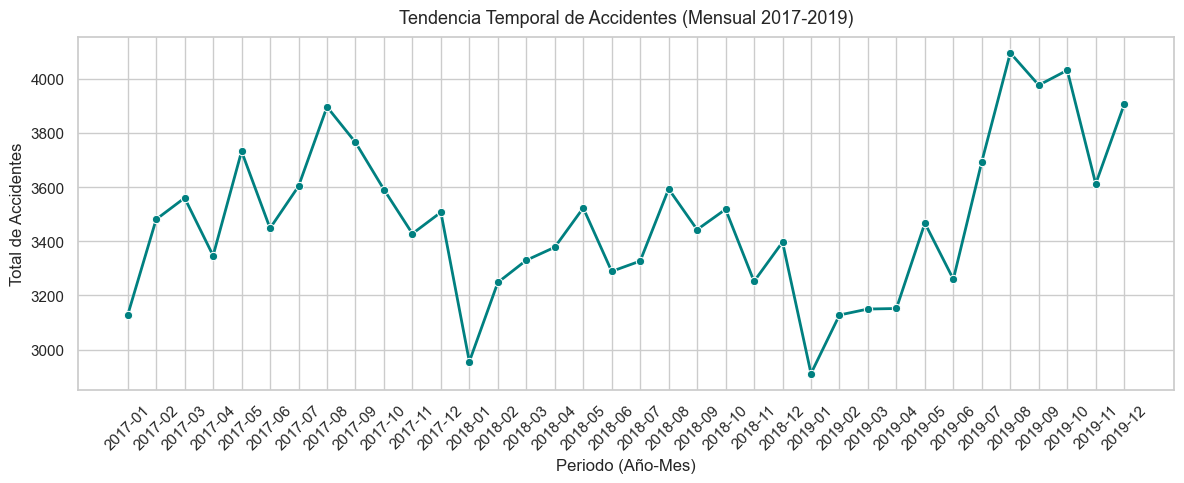

In [6]:
tendencia_temporal = df.groupby(['PERIODO', 'Mes']).size().reset_index(name='Total_Accidentes')
tendencia_temporal['Fecha_Eje'] = tendencia_temporal['PERIODO'].astype(str) + '-' + tendencia_temporal['Mes'].astype(str).str.zfill(2)

plt.figure(figsize=(12, 5))
sns.lineplot(data=tendencia_temporal, x='Fecha_Eje', y='Total_Accidentes', marker='o', color='teal', linewidth=2)

plt.title('Tendencia Temporal de Accidentes (Mensual 2017-2019)', fontsize=13, pad=10)
plt.xlabel('Periodo (Año-Mes)')
plt.ylabel('Total de Accidentes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

--- Límites para Lon ---
Límite Inferior Estadístico: -75.618636
Límite Superior Estadístico: -75.533149

--- Límites para Lat ---
Límite Inferior Estadístico: 6.172978
Límite Superior Estadístico: 6.330094



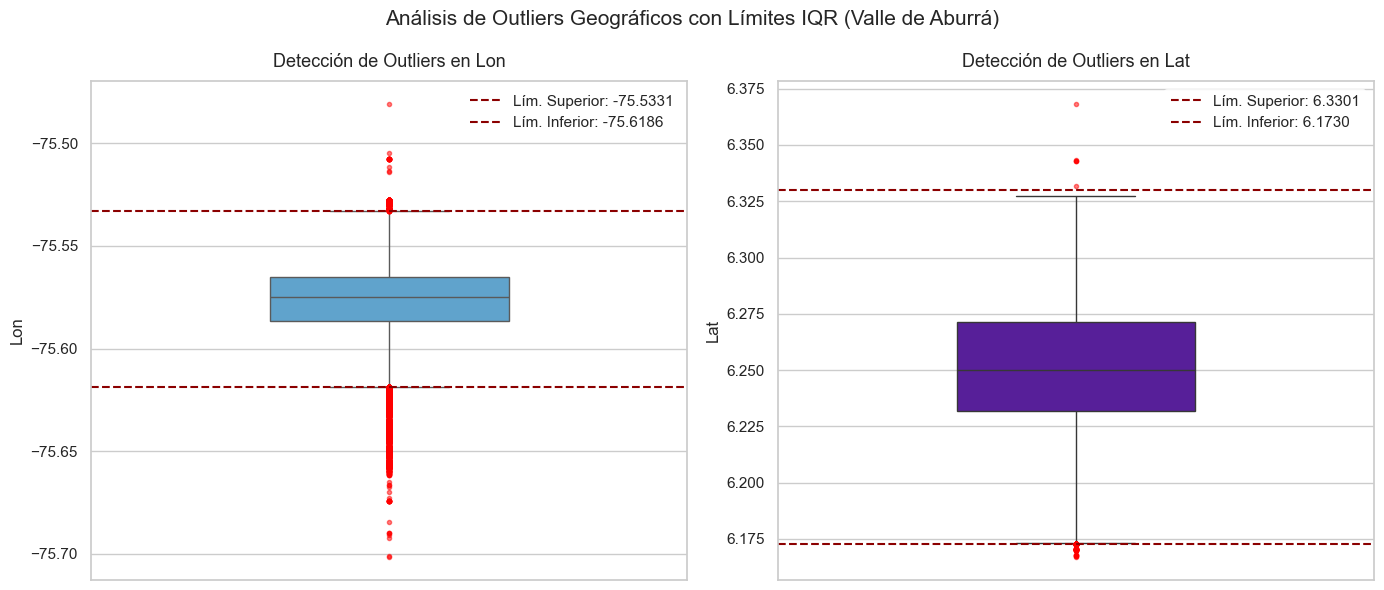

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

variables = ['Lon', 'Lat']
colores = ['#4ea8de', '#560bad']

for i, var in enumerate(variables):
    # 1. Calcular Cuartiles e IQR
    q1 = df[var].quantile(0.25)
    q3 = df[var].quantile(0.75)
    iqr = q3 - q1
    
    # 2. Calcular límites estadísticos duros
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    
    # 3. Dibujar el Boxplot base en su respectivo subgráfico
    sns.boxplot(data=df, y=var, ax=axes[i], color=colores[i], width=0.4,
                flierprops={"markerfacecolor": "red", "markeredgecolor": "red", "markersize": 3, "alpha": 0.5})
    
    # 4. Dibujar líneas horizontales para los límites
    axes[i].axhline(lim_sup, color='darkred', linestyle='--', linewidth=1.5, label=f'Lím. Superior: {lim_sup:.4f}')
    axes[i].axhline(lim_inf, color='darkred', linestyle='--', linewidth=1.5, label=f'Lím. Inferior: {lim_inf:.4f}')
    
    axes[i].set_title(f'Detección de Outliers en {var}', fontsize=13, pad=10)
    axes[i].set_ylabel(var)
    axes[i].legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')
    
    print(f"--- Límites para {var} ---")
    print(f"Límite Inferior Estadístico: {lim_inf:.6f}")
    print(f"Límite Superior Estadístico: {lim_sup:.6f}\n")

plt.suptitle('Análisis de Outliers Geográficos con Límites IQR (Valle de Aburrá)', fontsize=15, y=0.98)
plt.tight_layout()
plt.show()

C:\Users\Sara\AppData\Local\Temp\ipykernel_26744\3706890033.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_n.values, y=top_n.index, palette='Spectral')


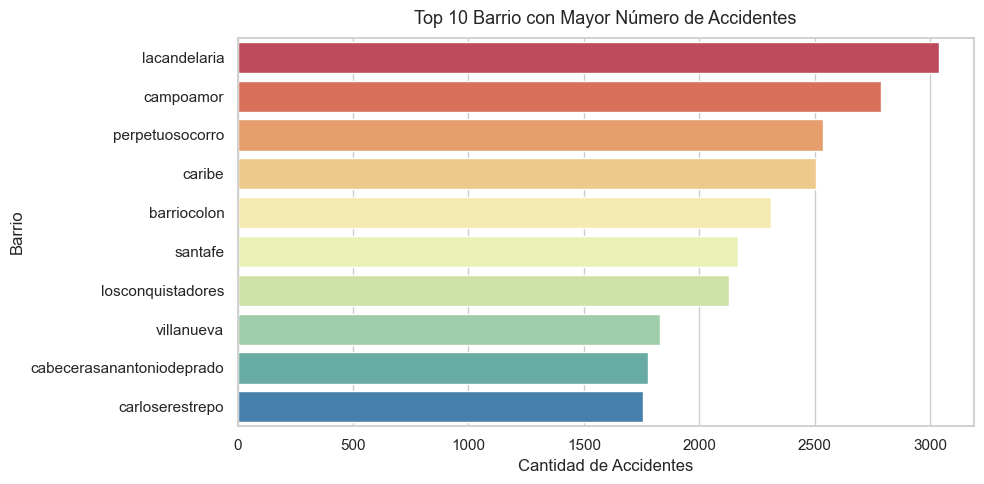

C:\Users\Sara\AppData\Local\Temp\ipykernel_26744\3706890033.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_n.values, y=top_n.index, palette='Spectral')


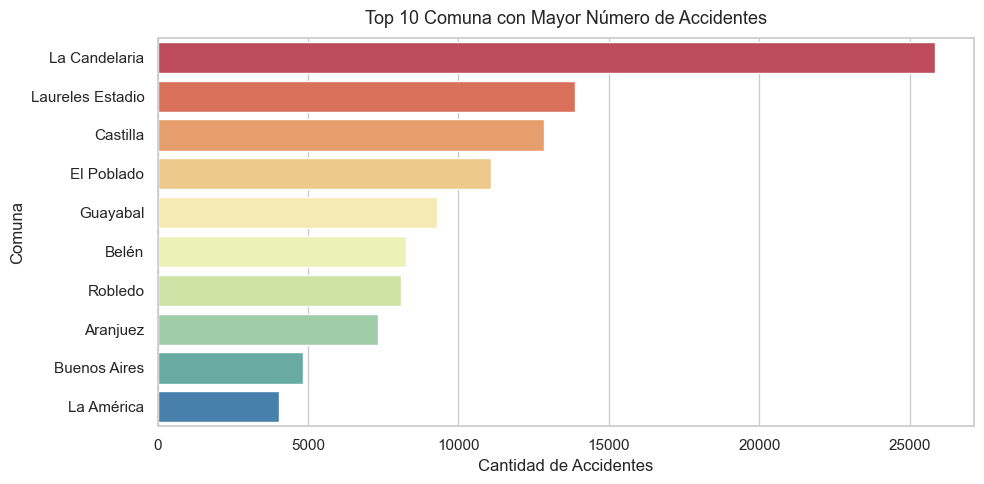

Columnas espaciales analizadas: ['BARRIO', 'COMUNA']


BARRIO
lacandelaria                 3037
campoamor                    2785
perpetuosocorro              2534
caribe                       2506
barriocolon                  2310
santafe                      2169
losconquistadores            2127
villanueva                   1830
cabecerasanantoniodeprado    1777
carloserestrepo              1757
sanbenito                    1736
guayaquil                    1721
sandiego                     1682
terminaldetransporte         1637
naranjal                     1542
Name: count, dtype: int64

COMUNA
La Candelaria                            25844
Laureles Estadio                         13883
Castilla                                 12855
El Poblado                               11078
Guayabal                                  9280
Belén                                     8260
Robledo                                   8092
Aranjuez                                  7326
Buenos Aires                              4822
La América                                4051
Manrique                                  3689
Doce de Octubre                           3439
Villa Hermosa                             3259
San Javier                                2045
Corregimiento de San Antonio de Prado     1901
Name: count, dtype: int64

In [8]:
# Distribución espacial por barrio y comuna
spatial_cols = [c for c in df.columns if c.upper() in ['BARRIO','BARRIOS','COMUNA','COMUNAS','BARRIO_NOMBRE','COMUNA_NOMBRE']]
if spatial_cols:
    for col in spatial_cols:
        top_n = df[col].value_counts().head(10)
        plt.figure(figsize=(10, 5))
        sns.barplot(x=top_n.values, y=top_n.index, palette='Spectral')
        plt.title(f'Top 10 {col.title()} con Mayor Número de Accidentes', fontsize=13, pad=10)
        plt.xlabel('Cantidad de Accidentes')
        plt.ylabel(col.title())
        plt.tight_layout()
        plt.show()
else:
    print('No se encontraron columnas de barrio/comuna para el análisis espacial.')

# Reporte de concentración espacial
if spatial_cols:
    print('Columnas espaciales analizadas:', spatial_cols)
    for col in spatial_cols:
        display(df[col].value_counts().head(15))


### Conclusiones EDA pre-modelado

- El análisis temporal permite identificar patrones de riesgo por hora, día de la semana y mes, lo que es clave para definir variables temporales en los modelos.
- El análisis espacial identifica los barrios y comunas con mayor concentración de accidentes, sugiriendo zonas prioritarias para variables geográficas.
- Las distribuciones de clase y gravedad, junto con los estadísticos descriptivos, sustentan la selección de características relevantes para el modelado predictivo.
- Estos hallazgos justifican la limpieza de datos y el diseño de variables antes de la etapa de entrenamiento.

In [15]:
%pip install holidays

  Obtaining dependency information for holidays from https://files.pythonhosted.org/packages/00/a2/05cbe4e2309a08a09bbfab04d3d37d687b5852abf7d037fea19313d2eb60/holidays-0.96-py3-none-any.whl.metadata
     ---------------------------------------- 0.0/53.0 kB ? eta -:--:--
     ------- -------------------------------- 10.2/53.0 kB ? eta -:--:--
     ------- -------------------------------- 10.2/53.0 kB ? eta -:--:--
     ------- -------------------------------- 10.2/53.0 kB ? eta -:--:--
     ----------------------------- -------- 41.0/53.0 kB 178.6 kB/s eta 0:00:01
     -------------------------------------- 53.0/53.0 kB 195.3 kB/s eta 0:00:00
  Obtaining dependency information for python-dateutil<3,>=2.9.0.post0 from https://files.pythonhosted.org/packages/ec/57/56b9bcc3c9c6a792fcbaf139543cee77261f3651ca9da0c93f5c1221264b/python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
   -----------------------


[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# 4.3 Unión de Tablas e Ingeniería de Características

In [24]:
import pandas as pd
import holidays

# 1. Cargar datos actuales de Staging
df = pd.read_csv('../Datos/Staging/accidentes_staging.csv')
# 2. Crear una columna de fecha real (tipo datetime) interna para hacer los cálculos
fechas_reales = pd.to_datetime(
    pd.DataFrame({'year': df['PERIODO'], 'month': df['Mes'], 'day': df['Dia']}), 
    errors='coerce'
)

# 3. Generar variables temporales - hora, día de la semana, mes, fin de semana, festivo
# Variable A: Hora del día (es la misma 'Hora_num')
df['hora_dia'] = df['Hora_num'].astype(int)

# Variable B: Día de la semana (0 = Lunes, 6 = Domingo)
df['dia_semana'] = fechas_reales.dt.dayofweek

# Variable C: Mes
df['mes_num'] = df['Mes'].astype(int)

# Variable D: Fin de semana (1 si es Sábado o Domingo, 0 si es día de semana)
# .dt.dayofweek devuelve 5 para Sábado y 6 para Domingo
df['es_fin_semana'] = df['dia_semana'].apply(lambda x: 1 if x in [5, 6] else 0)

# Variable E: Festivo en Colombia (1 si es festivo, 0 si no)
# Inicializamos el calendario de Colombia para los años del dataset
festivos_colombia = holidays.Colombia(years=[2017, 2018, 2019])

# Evaluamos cada fecha en el calendario de festivos
df['es_festivo'] = fechas_reales.apply(lambda x: 1 if x in festivos_colombia else 0)

# Guardamos el DataFrame con las nuevas columnas sobreescribiendo el staging
df.to_csv('../Datos/Staging/accidentes_staging_enriquecido.csv', index=False, encoding='utf-8')

print("¡Variables temporales generadas exitosamente!")
print("\nColumnas nuevas agregadas:")
print(df[['hora_dia', 'dia_semana', 'mes_num', 'es_fin_semana', 'es_festivo']].head())

C:\Users\Sara\AppData\Local\Temp\ipykernel_23480\3747346165.py:5: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../Datos/Staging/accidentes_staging.csv')


¡Variables temporales generadas exitosamente!

Columnas nuevas agregadas:
   hora_dia  dia_semana  mes_num  es_fin_semana  es_festivo
0         8           3        7              0           1
1        16           3        6              0           0
2        16           6        7              1           0
3        18           2        3              0           0
4        20           2        7              0           0


In [25]:
import pandas as pd
import numpy as np

# 3. Codificar variables cíclicas usando Seno y Coseno para Hora, Día de la Semana y Día del Año
df['hora_sin'] = np.sin(2 * np.pi * df['hora_dia'] / 24.0)
df['hora_cos'] = np.cos(2 * np.pi * df['hora_dia'] / 24.0)

df['dia_semana_sin'] = np.sin(2 * np.pi * df['dia_semana'] / 7.0)
df['dia_semana_cos'] = np.cos(2 * np.pi * df['dia_semana'] / 7.0)

# Extraemos el día del año (1 a 365/366, si es bisiesto) y los días totales de ese año específico 
dia_del_ano = fechas_reales.dt.dayofyear
dias_totales_ano = fechas_reales.dt.is_leap_year.map(lambda x: 366.0 if x else 365.0)

df['dia_ano_sin'] = np.sin(2 * np.pi * dia_del_ano / dias_totales_ano)
df['dia_ano_cos'] = np.cos(2 * np.pi * dia_del_ano / dias_totales_ano)

# Guardar el DataFrame con las nuevas columnas sobreescribiendo el staging
df.to_csv('../Datos/Staging/accidentes_staging_enriquecido.csv', index=False, encoding='utf-8')

print("¡Variables cíclicas (Seno/Coseno) codificadas y guardadas con éxito!")
# Ver un ejemplo de cómo se transformaron las horas
df[['hora_dia', 'hora_sin', 'hora_cos']].drop_duplicates().sort_values('hora_dia').head(5)

¡Variables cíclicas (Seno/Coseno) codificadas y guardadas con éxito!


,hora_dia,hora_sin,hora_cos
20,0,0.000000,1.000000
34,1,0.258819,0.965926
437,2,0.500000,0.866025
85,3,0.707107,0.707107
89,4,0.866025,0.500000


In [ ]:
def extraer_comuna_real(cbml):
    cbml_str = str(cbml).strip().replace('.0', '') # Limpiar formatos de flotantes
    
    # Caso 1: Códigos cortos de 4 dígitos (ej: '0607' o '607')
    if len(cbml_str) <= 4:
        # Rellenamos a 4 caracteres para asegurar que tenga la forma MMBB (Municipio/Barrio o Comuna/Barrio)
        codigo_fijo = cbml_str.zfill(4)
        return codigo_fijo[:2]
    
    # Caso 2: Códigos estándar largos (ej: '60980380285')
    elif len(cbml_str) >= 10:
        return cbml_str[:2]
    

df = pd.read_csv('../Datos/Staging/accidentes_staging_enriquecido.csv')
df['fecha_dt'] = pd.to_datetime(pd.DataFrame({'year': df['PERIODO'], 'month': df['Mes'], 'day': df['Dia']}))
df = df.sort_values('fecha_dt').reset_index(drop=True)

# Variable A: Comuna (A partir del CBML - Sin peligro de fuga)
# El CBML suele ser un texto o número largo. Los primeros 2 dígitos son la comuna.
# Aplicamos la función sobre la columna CBML original
def extraer_barrio_real(cbml):
    cbml_str = str(cbml).strip().replace('.0', '')
    if len(cbml_str) <= 4:
        return cbml_str.zfill(4)[2:4]
    elif len(cbml_str) >= 10:
        return cbml_str[2:4]
    return None

df['comuna_ext'] = df['CBML'].apply(extraer_comuna_real)
df['barrio_ext'] = df['CBML'].apply(extraer_barrio_real)


# Variable B: Promedio de accidentes históricos por barrio 
# Paso 1: Contar cuántos accidentes ocurrieron por Barrio en cada Fecha
accidentes_diarios = df.groupby(['fecha_dt', 'BARRIO']).size().reset_index(name='accidentes_del_dia')

# Ordenamos cronológicamente este resumen por barrio
accidentes_diarios = accidentes_diarios.sort_values('fecha_dt')

# Paso 2: Calcular la suma acumulada de accidentes pasados (Shifted para excluir el día actual)
# El .shift(1) es el "secreto": asegura que el día de HOY no se cuente en el promedio histórico del pasado
accidentes_diarios['suma_accidentes_pasados'] = accidentes_diarios.groupby('BARRIO')['accidentes_del_dia'].transform(lambda x: x.cumsum().shift(1)).fillna(0)

# Paso 3: Contar cuántos días han transcurrido históricamente para ese barrio
accidentes_diarios['dias_transcurridos'] = accidentes_diarios.groupby('BARRIO').cumcount()

# Paso 4: Calcular el promedio acumulado real (Evitando división por cero con np.where)
accidentes_diarios['prom_accidentes_historico_barrio'] = np.where(
    accidentes_diarios['dias_transcurridos'] > 0,
    accidentes_diarios['suma_accidentes_pasados'] / accidentes_diarios['dias_transcurridos'],
    0 # Si es el primer día que vemos el barrio, el promedio histórico es 0
)

# Paso 5: Cruzar esta métrica de vuelta a nuestro DataFrame original
df = pd.merge(
    df, 
    accidentes_diarios[['fecha_dt', 'BARRIO', 'prom_accidentes_historico_barrio']], 
    on=['fecha_dt', 'BARRIO'], 
    how='left'
)

# Eliminamos la columna de fecha interna para mantener el staging limpio
df = df.drop(columns=['fecha_dt'])

# Guardamos en Staging sobreescribiendo el archivo seguro
df.to_csv('../Datos/Staging/accidentes_staging_enriquecido.csv', index=False, encoding='utf-8')

print("¡Variables agregadas por barrio calculadas exitosamente sin fuga de datos!")

C:\Users\Sara\AppData\Local\Temp\ipykernel_23480\585042344.py:15: DtypeWarning: Columns (3,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../Datos/Staging/accidentes_staging_enriquecido.csv')


¡Variables agregadas por barrio calculadas exitosamente sin fuga de datos!


In [27]:
df[['PERIODO', 'Mes', 'Dia', 'BARRIO', 'CBML','comuna_ext', 'prom_accidentes_historico_barrio']].head(5)

,PERIODO,Mes,Dia,BARRIO,CBML,comuna_ext,prom_accidentes_historico_barrio
0,2017,1,1,cabecerasanantoniodeprado,8000,80,0.0
1,2017,1,1,cabecerasanantoniodeprado,8000,80,0.0
2,2017,1,1,kennedy,0607,06,0.0
3,2017,1,1,areadeexpansionpajarito,60980380285,60,0.0
4,2017,1,1,asomaderano3,0916,09,0.0


In [30]:
pd.set_option('display.max_columns', None)  
pd.set_option('display.max_rows', None)     
pd.set_option('display.width', 1000)       

df.head(10)

,Lon,Lat,OBJECTID,RADICADO,HORA,Dia_sem,PERIODO,CLASE,DIRECCION,DIRECCION_ENC,CBML,TIPO_GEOCOD,GRAVEDAD,BARRIO,COMUNA,DISENO,Mes,Dia,FECHA,Hora_num,TW,Dia_Sem_REAL,hora_dia,dia_semana,mes_num,es_fin_semana,es_festivo,hora_sin,hora_cos,dia_semana_sin,dia_semana_cos,dia_ano_sin,dia_ano_cos,comuna_ext,prom_accidentes_historico_barrio
0,-75.648182,6.185473,514618,1565408,03:00 AM,DOMINGO,2017,CHOQUE,CL 39 D sur CR 66 A,CL S 039 D 066 A 000 00000,8000,Malla vial,SOLO DAÑOS,cabecerasanantoniodeprado,Corregimiento de San Antonio de Prado,Tramo de via,1,1,2017-01-01,3,2017-01-01 03:00:00,DOMINGO,3,6,1,1,1,0.707107,0.707107,-0.781831,0.62349,0.017213,0.999852,80,0.0
1,-75.648998,6.186579,514675,1565786,04:00 PM,DOMINGO,2017,ATROPELLO,CL 38 B sur CR 69,CL S 038 B 069 000 00000,8000,Malla vial,HERIDO,cabecerasanantoniodeprado,Corregimiento de San Antonio de Prado,Tramo de via,1,1,2017-01-01,16,2017-01-01 16:00:00,DOMINGO,16,6,1,1,1,-0.866025,-0.500000,-0.781831,0.62349,0.017213,0.999852,80,0.0
2,-75.581983,6.287505,514674,1565185,01:30 AM,DOMINGO,2017,CHOQUE,CR 76 CL 91,CR 076 091 000 00000,0607,Malla vial,HERIDO,kennedy,Doce de Octubre,Tramo de via,1,1,2017-01-01,1,2017-01-01 01:00:00,DOMINGO,1,6,1,1,1,0.258819,0.965926,-0.781831,0.62349,0.017213,0.999852,06,0.0
3,-75.613491,6.284049,507561,00020,08:30 AM,DOMINGO,2017,CHOQUE,CL 66 CR 103 B - 15,CL 066 103 B 015 00000,60980380285,Nomenclatura con Interior,MUERTO,areadeexpansionpajarito,Corregimiento de San Cristóbal,NaN,1,1,2017-01-01,8,2017-01-01 08:00:00,DOMINGO,8,6,1,1,1,0.866025,-0.500000,-0.781831,0.62349,0.017213,0.999852,60,0.0
4,-75.557658,6.214653,515610,1565438,07:00 PM,DOMINGO,2017,CAIDA OCUPANTE,CL 16 CR 28,CL 016 028 000 00000,0916,Malla vial cruce invertido,HERIDO,asomaderano3,Buenos Aires,Tramo de via,1,1,2017-01-01,19,2017-01-01 19:00:00,DOMINGO,19,6,1,1,1,-0.965926,0.258819,-0.781831,0.62349,0.017213,0.999852,09,0.0
5,-75.575084,6.264130,515611,1565436,09:45 PM,DOMINGO,2017,OTRO,CL 67 CR 64,CL 067 064 000 00000,0517,Malla vial,HERIDO,caribe,Castilla,Tramo de via,1,1,2017-01-01,21,2017-01-01 21:00:00,DOMINGO,21,6,1,1,1,-0.707107,0.707107,-0.781831,0.62349,0.017213,0.999852,05,0.0
6,-75.615447,6.254136,515612,1565203,04:00 AM,DOMINGO,2017,CHOQUE,CL 39 CR 96,CL 039 096 000 00000,1310,Malla vial,HERIDO,veintedejulio,San Javier,Tramo de via,1,1,2017-01-01,4,2017-01-01 04:00:00,DOMINGO,4,6,1,1,1,0.866025,0.500000,-0.781831,0.62349,0.017213,0.999852,13,0.0
7,-75.548187,6.262217,515613,1565224,02:15 AM,DOMINGO,2017,CHOQUE,CR 36 A CL 68,CR 036 A 068 000 00000,0308,Malla vial cruce invertido,HERIDO,manriqueoriental,Manrique,Interseccion,1,1,2017-01-01,2,2017-01-01 02:00:00,DOMINGO,2,6,1,1,1,0.500000,0.866025,-0.781831,0.62349,0.017213,0.999852,03,0.0
8,-75.602116,6.262675,515694,1565818,11:00 PM,DOMINGO,2017,CHOQUE,CL 49 DD CR 83 A,CL 049 DD 083 A 000 00000,1213,Malla vial,HERIDO,calasanzpartealta,La América,Tramo de via,1,1,2017-01-01,23,2017-01-01 23:00:00,DOMINGO,23,6,1,1,1,-0.258819,0.965926,-0.781831,0.62349,0.017213,0.999852,12,0.0
9,-75.582471,6.297758,515695,1565202,10:00 AM,DOMINGO,2017,CHOQUE,CR 83 CL 97 C,CR 083 097 C 000 00000,0608,Malla vial,HERIDO,picacho,Doce de Octubre,Tramo de via,1,1,2017-01-01,10,2017-01-01 10:00:00,DOMINGO,10,6,1,1,1,0.500000,-0.866025,-0.781831,0.62349,0.017213,0.999852,06,0.0
